In [1]:
import numpy as np
import rebound as rb
from matplotlib import pyplot as plt
import celmech as cm
from celmech.disturbing_function import get_fg_coefficients
from celmech.nbody_simulation_utilities import add_canonical_heliocentric_elements_particle
from celmech.poisson_series import PoissonSeries,PSTerm
import sys
sys.path.insert(0,"../00_code/")

In [2]:
def Deltas_to_pvars(Deltas,resonances,masses):
    sim = rb.Simulation()
    sim.add(m=1)
    Period = 1
    add_canonical_heliocentric_elements_particle(masses[0],{'a' : Period**(2/3)},sim)
    for Delta,mass,pq in zip(Deltas,masses[1:],resonances):
        p,q = pq
        Period *= (1+Delta)*p/(p-q)
        add_canonical_heliocentric_elements_particle(mass,{'a' : Period**(2/3)},sim)
    sim.move_to_com()

    return cm.Poincare.from_Simulation(sim)

# set up example system

(the draft [here](https://www.overleaf.com/read/khvmzgvwjvqq#5c55ba) may or may not be helpful...)

I'll use Kepler-223 as my exaple system, which will be modelled with a `ResonantChainPoissonSeries`
object. 

This object serves as a representation of the Hamiltonian governing a resonant chain system.
The Hamiltonian has $3N_{\rm pl}-2$ dynamical variables where $N_{\rm pl}$ is the number of planets in the chain (4 in the case of Kepler-223).

To introduce the variables of the model, we first introduce the constants $\rho_i = \frac{m_i}{m_1}\sqrt{\frac{a_i}{a_{1,0}}}$ where $m_i$ is the $i$th planet's mass, $a_i$ its semi-major axis, and $a_{1,0}$ is a reference semi-major axis taken to be close to the innermost planet's semimajor axis.

The variables of the model are:
    $$(y_1,...,y_{4},v_1,...,v_4,\phi_1,\phi_2,x_1,...,x_4,u_1,...,u_{4},\Phi_1,\Phi_2)$$
    where
    $$
    \begin{align}
     x_i + {\rm i}y_i&\approx \left(\frac{\rho_i}{2}\right)^{1/2}e_i\exp[{\rm i}(\varpi_i - \theta_{i,i+1})] 
    \\
    u_i + {\rm i}v_i&\approx \left(\frac{\rho_i}{2}\right)I_i\exp[{\rm i}( \Omega_i-\theta_{i,i+1})] 
    \end{align}
    $$
with $\theta_{i,i+1} = j_i\lambda_{i+1}-(j_i-k_i)\lambda_{i}$. The $\phi_i$ are the three-body resonant angles:
    $$
    \begin{align}
     \phi_1 &= \lambda_3 -2\lambda_2 + \lambda_1
    \\
    \phi_2 & = \lambda_4 - 3\lambda_3 + 2\lambda_2
    \end{align}
    $$
and the $\Phi_i$ are momenta canonically conjugate to the $\phi_i$ given by
    $$
    \begin{align}
    \Phi_1  &=  \frac{1}{2}\frac{\Delta a_{1}}{a_{1,0}} 
    \\
    \Phi_2 & =\frac{\Delta a_{1}}{a_{1,0}} + \frac{1}{2}\frac{\Delta a_{2}}{a_{1,0}}
    \end{align}
    $$
where the $\Delta a_{i}$ 
are deviations of planets' semi-major axis from reference values $a_{i,0}$ defined to be exaclty resonant, i.e., 
$ a_{2,0} = \left(\frac{j_1}{j_1-k_1}\right)^{2/3}a_{1,0}$.

Additionally, the Hamiltonian depends on an AMD-like constant 
$$K_2 \approx =\sum_{i=1}^{N_{\rm pl}}\rho_i\left(\frac{\Delta a_i}{a_{i,0}} - e_i^2-I_i^2\right)$$

In [3]:
from resonant_chains import get_chain_rebound_sim,get_chain_hpert, ResonantChainPoissonSeries

In [4]:
resonances = [(4,1),(3,1),(4,1)] # j:j-k resonances of the chain 
                                 # enumerated in the form [(j1,k1),...,(jn,kn)] 
                                 # starting with the resonance of the innermost planet pair
masses = np.array([6.6,4.5,7.1,4.3]) * 3.e-6 # masses of planets, from inner to outer, in units of stellar mass.


Here we generate an expression for the perturbative part of the Hamiltion, i.e., all the disturbing function terms that will be included in our model. This is handled by the function `get_chain_hpert` defined in `resonant_chains.py`.

`get_chain_hpert` returns a Poisson series object (see, e.g., Section 2.6 of [here](https://ui.adsabs.harvard.edu/abs/2024ApJ...972...64H/abstract)) that contains a series representation of all the disturbing function terms.

In [5]:
max_order = 3 # maximum order in e/i for perturbative model
max_dl_order = 1 # maximum order in \delta\Lambda / \Lambda for perturbative model
hpert = get_chain_hpert(resonances,masses,max_dl_order)
print(f"hpert is a {type(hpert)} containing {len(hpert.terms)} terms")

adding terms for 4:3 MMR between 1 and 2
adding terms for 2:1 MMR between 1 and 3
adding terms for 3:2 MMR between 2 and 3
adding terms for 2:1 MMR between 2 and 4
adding terms for 4:3 MMR between 3 and 4
hpert is a <class 'celmech.poisson_series.PoissonSeries'> containing 65 terms


Now we'll make our `ResonantChainPoissonSeries` object, which takes a `PoissonSeries` representing our disturbing function terms and generates a representation of our Hamiltonian.

In [6]:
rc = ResonantChainPoissonSeries(
    resonances,
    masses,
    hpert,
    max_order = max_order
)

In [7]:
from resonant_chains import newton_solve2 # for deteriming equlibirum configurations via root-finding

Now we'll find an elliptic equilibrium of the dynamics via root-finding.

In [8]:
rc.dK2 = 0
# rc.M stores the number of angular d.o.f.'s
#
print("The Hamiltonian modeled by 'rc' has:")
print(f"\t {rc.M} angular degrees of freedom (i.e., 3-body angles)")
print(f"\t {rc.N_planar} cartesian-style conjugate pairs when restricted to planar models (i.e, x_i/y_i variable pairs)")

guess = np.zeros(2*(rc.N_planar + rc.M))

# a judicious choice of equilibrium resonant angle values
# is often helpful for finding an initial elliptic equilibrium  
phi1_guess,phi2_guess= (175 / 180) * np.pi , np.pi * (65/180) 

guess[rc.N_planar:rc.N_planar+rc.M] = phi1_guess,phi2_guess

# Newton-Raphson search for equilibirum
z_eq = newton_solve2(
    rc.planar_flow_and_jacobian,
    guess)

# Jacobian evaluated at identified equilibirum
Df_eq = rc.planar_jacobian(z_eq)

# check that all eienvalues are imaginary
elliptic_eq_bool = np.all(np.isclose(np.real(np.linalg.eigvals(Df_eq)),0))
print(f"Elliptic equilibrium identified successfully?  {elliptic_eq_bool}")

The Hamiltonian modeled by 'rc' has:
	 2 angular degrees of freedom (i.e., 3-body angles)
	 4 cartesian-style conjugate pairs when restricted to planar models (i.e, x_i/y_i variable pairs)
Elliptic equilibrium identified successfully?  True


# Equilibrium family
Now that we've identified an elliptic equilibrium of the resonant dynamics, we'll construct a whole family for different values of $K_2$
(Note: this is stored as the `ResonantChainPoissonSeries.dK2` attribute)

In [9]:
Npts = 60
eqs = np.zeros((Npts,guess.size))
K2vals = np.linspace(-0.001,0.005,Npts)
for i,K2 in enumerate(K2vals):
    rc.dK2 = K2
    guess = newton_solve2(
        rc.planar_flow_and_jacobian,
        guess
    )
    eqs[i] = guess

Convert equilibria to orbital elements.
We'll use the instance method `ResonantChainPoissonSeries.real_planar_vars_to_pvars` to convert our Poisson series model variables to celmech `Poincare` objects. 

In [10]:
Npl = rc.N_planar # number of planets is the same as rc.N_planar
eq_periods, eq_eccs = [np.zeros((Npts,Npl)) for _ in range(2)]
for i,eq in enumerate(eqs):
    # note-- if a value of dK2 is not passed explicitly as
    # a keyword arg then 'real_planar_vars_to_pvars' assumes
    # the 'ResonantChainPoissonSeries' instance's current
    # value. Since we looped over different values above
    # we need to pass it explicitly
    pvars = rc.real_planar_vars_to_pvars(
        eq,
        dK2 = K2vals[i] 
    )
    eq_eccs[i] = [p.e for p in pvars.particles[1:]]
    eq_periods[i] = [p.P for p in pvars.particles[1:]]

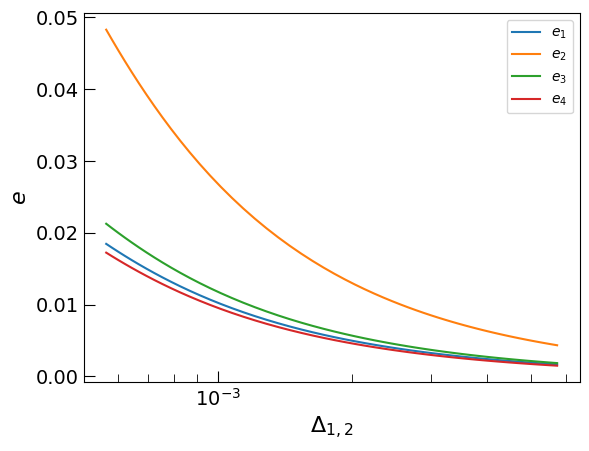

In [11]:
j_in,k_in = resonances[0]
Delta_in = (j_in-k_in) * eq_periods.T[1] / eq_periods.T[0] / j_in - 1 
plt.plot(Delta_in,eq_eccs,label=[f"$e_{i+1}$" for i in range(4)])
plt.xscale('log')
plt.ylabel("$e$",fontsize=16)
plt.xlabel(r"$\Delta_{1,2}$",fontsize=16)
plt.tick_params(direction='in',size=8,labelsize=14)
plt.tick_params(direction='in',size=6,which='minor')
plt.legend()

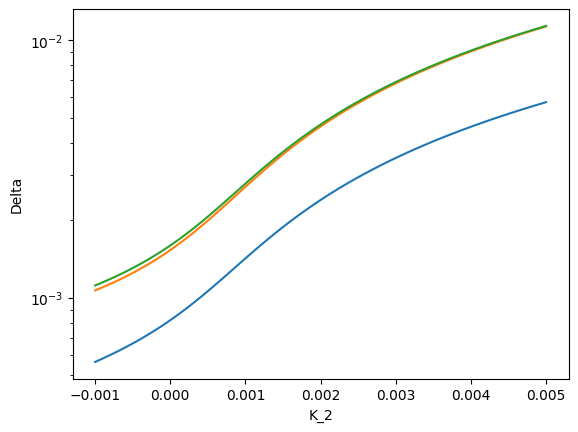

In [12]:
for jk,p1,p2 in zip(resonances,eq_periods.T[:-1],eq_periods.T[1:]):
    j,k = jk
    Delta= (j-k) * p2  / p1 /j -1
    plt.plot(K2vals,Delta)
plt.xlabel("K_2")
plt.ylabel("Delta")
plt.yscale('log')

# generating n-body simulations at equilibria
We can use the equilibria we determined above to initialize a rebound simulations.
This will rely on the same `real_planar_vars_to_pvars` method we used above.

In [13]:
sim_indx = Npts//2 # we'll pick an equilibrium halfway along our family
pvars = rc.real_planar_vars_to_pvars(
    eqs[sim_indx],
    dK2 = K2vals[sim_indx]
)
sim_eq = pvars.to_Simulation()
sim_eq.status()

---------------------------------
REBOUND version:     	4.4.11
REBOUND built on:    	Nov 18 2025 14:41:09
Number of particles: 	5
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x11c343250, m=1.0 x=-5.954185581612999e-05 y=-3.54656015542542e-05 z=0.0 vx=3.1471382003657626e-05 vy=-2.6002628330541256e-05 vz=0.0>
<rebound.particle.Particle object at 0x119d4add0, m=1.98e-05 x=-0.1467425652370799 y=0.9878696667374075 z=0.0 vx=-0.9896293945928496 vy=-0.1431279404121761 vz=0.0>
<rebound.particle.Particle object at 0x11c343250, m=1.35e-05 x=0.2727221131598137 y=1.1870022701668403 z=0.0 vx=-0.881877777321946 vy=0.19497706702487488 vz=0.0>
<rebound.particle.Particle object at 0x119d4add0, m=2.13e-05 x=1.5838329623810932 y=-0.004892093062708964 z=0.0 vx=0.0012221066970241803 vy=0.7962796097202267 vz=0.0>
<rebound.particle.Particle object at 0x11c343250, m=1.29e-05 x=1.94

In [14]:
sim_eq.integrator='whfast'
sim_eq.dt = sim_eq.particles[1].P / 25.
Tfin = sim_eq.particles[1].P  * 1e5
sim_eq.save_to_file("kep223_eq_example.sa",interval=Tfin/256,delete_file=True)
print("integrating...")
sim_eq.integrate(Tfin)


integrating...


### Now we'll plot up the results 

Text(0, 0.5, '$\\theta$')

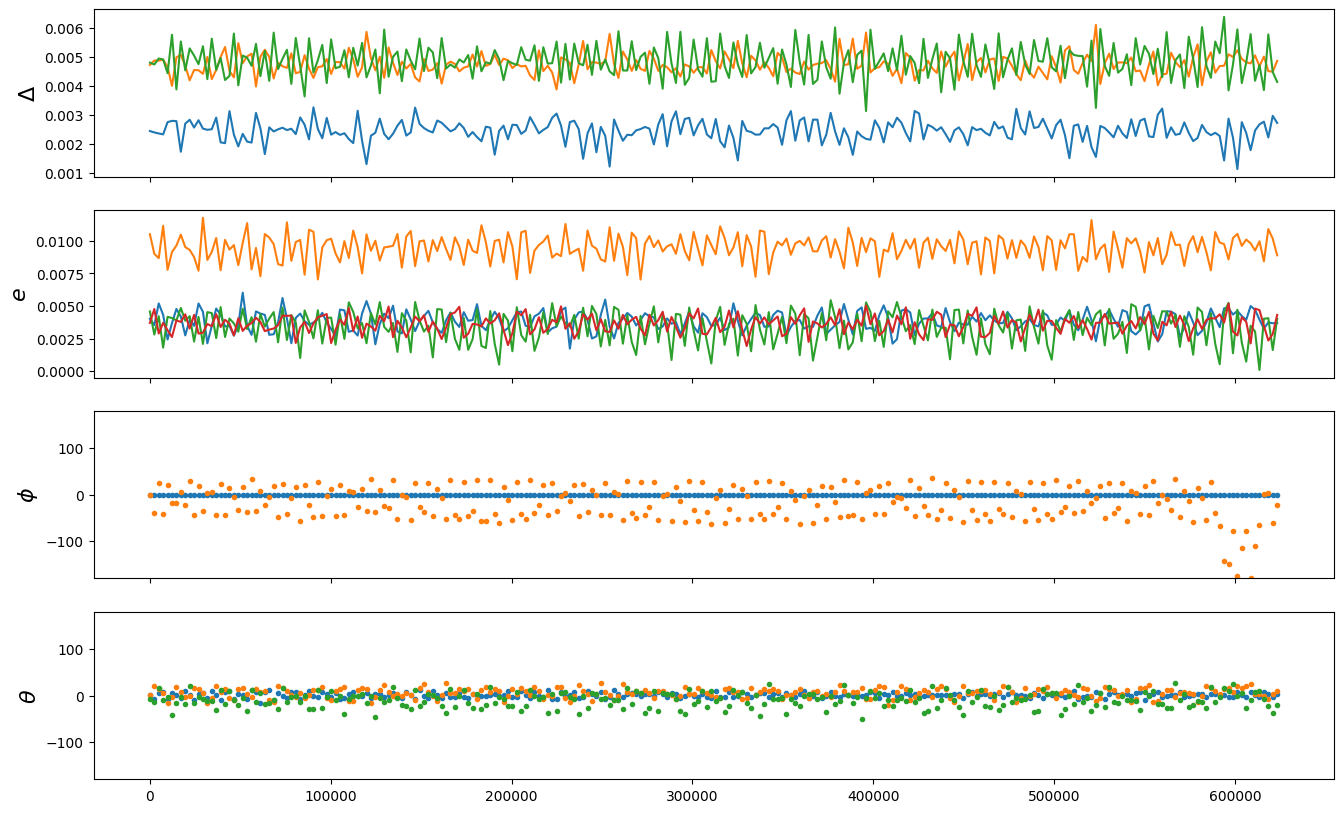

In [15]:
fig,ax_list = plt.subplots(4,1,sharex=True,figsize=(16,10),sharey='row')
mymod = lambda x: np.mod(x+np.pi,2*np.pi)-np.pi


# read in a results dictionary
results = cm.nbody_simulation_utilities.get_simarchive_integration_results("kep223_eq_example.sa",coordinates='heliocentric')

# store complex eccentricities
results['z'] = results['e']*np.exp(1j*results['pomega'])

# Plot Deltas
for jk,p1,p2 in zip(resonances,results['P'][:-1],results['P'][1:]):
    j,k = jk
    D = (j-k)*p2/p1/j-1
    ax_list[0].plot(results['time'],D)
ax_list[0].set_ylabel(r"$\Delta$",fontsize=16)

# Plot eccentricities
for ecc in results['e']:
    ax_list[1].plot(results['time'],ecc)
ax_list[1].set_ylabel(r"$e$",fontsize=16)

# Plot 3-body angles
for l,row in enumerate(rc.Tmtrx[2:2+rc.M,:rc.N_planar]):
    phi = mymod(l*(row @ results['l'] - (row @ results['l'])[0]))
    ax_list[2].plot(results['time'],180*phi/np.pi,'.')
ax_list[2].set_ylim(-180,180)
ax_list[2].set_ylabel(r"$\phi$",fontsize=16)

# plot 2-body resonant angles
all_theta = []
for l,jk in enumerate(resonances):
    j,k  = jk
    f,g = get_fg_coefficients(j,k)
    argZ = np.angle(f*results['z'][l]+g*results['z'][l+1])
    theta = mymod(j * results['l'][l+1] + (k-j)*results['l'][l] - k * argZ + np.pi)
    all_theta.append(theta)
    ax_list[3].plot(results['time'],180*theta/np.pi,'.')
ax_list[3].set_ylim(-180,180)
ax_list[3].set_ylabel(r"$\theta$",fontsize=16)

### mean to osculating elements
We can actually do better by noting that the resonant model we've constructed is implicitly formulated in terms of 'mean' variables that differ from a system's osculating elements by a near-identity transformation (see, e.g., [celmech paper](https://ui.adsabs.harvard.edu/abs/2022AJ....164..179H/abstract) section 5.4). We'll use celmech's generating function capabilities to apply the inverse of this transformation to our resonant equilibrium data.

We're going to create a `FirstOrderGeneratingFunction` object, initializing it with parameters corresponding to exact nominal resonant. We could try to be more precise by creating a new object for each equilibirum configuration, but this isn't really worth the computational cost. Instead, we can feed different equilibrium configurations (e.g., by changing `sim_indx`) to our single `FirstOrderGeneratingFunction` object, `chi`, to correct their elements from mean to osculation. We just account for interactions between adjacent pairs in the generating function constructed below.

In [16]:
from celmech.lie_transformations import FirstOrderGeneratingFunction
exact_res_pvars=Deltas_to_pvars([0 for _ in range(rc.N_planar-1)],resonances,masses)
chi = FirstOrderGeneratingFunction(exact_res_pvars)
Npl = rc.N_planar

for i in range(1,Npl):
    jres,kres = resonances[i-1]
    
    # add 0th order (i.e., synodic) terms from disturbing function
    

    # add cosine terms 
    print("pair {},{}".format(i,i+1))
    print("\t correctiong for 0th order terms")
    chi.add_zeroth_order_term(i,i+1)    
    if kres==2:
        jres = jres // 2
        print(f"\t correcting for res.: {jres}:{jres-1}")
        chi.add_cosine_term(
            [jres,1-jres,-1,0,0,0],
            indexIn=i,
            indexOut=i+1
        )
        chi.add_cosine_term(
            [jres,1-jres,0,-1,0,0],
            indexIn=i,
            indexOut=i+1
        )
    # loop over j':j'-1 resonance where
    # j' is offset from the resonances included
    # in our model by ±k
    for k in range(1,5):
        print(f"\t correcting for res.: {jres+k}:{jres+k-1}")

        chi.add_cosine_term(
            [jres+k,1-jres-k,-1,0,0,0],
            indexIn=i,
            indexOut=i+1
        )
        print(f"\t res.: {jres-k}:{jres-k-1}")
        chi.add_cosine_term(
            [jres-k,1-jres+k,-1,0,0,0],
            indexIn=i,
            indexOut=i+1
        )
        chi.add_cosine_term(
            [jres+k,1-jres-k,0,-1,0,0],
            indexIn=i,
            indexOut=i+1
        )
        chi.add_cosine_term(
            [jres-k,1-jres+k,0,-1,0,0],
            indexIn=i,
            indexOut=i+1
        )
# The initial evaluation has some overhead. 
# We'll just run it now to get it out of the way--
# this has no bearing on our ultimate results
chi.mean_to_osculating()

pair 1,2
	 correctiong for 0th order terms
	 correcting for res.: 5:4
	 res.: 3:2
	 correcting for res.: 6:5
	 res.: 2:1
	 correcting for res.: 7:6
	 res.: 1:0
	 correcting for res.: 8:7
	 res.: 0:-1
pair 2,3
	 correctiong for 0th order terms
	 correcting for res.: 4:3
	 res.: 2:1
	 correcting for res.: 5:4
	 res.: 1:0
	 correcting for res.: 6:5
	 res.: 0:-1
	 correcting for res.: 7:6
	 res.: -1:-2
pair 3,4
	 correctiong for 0th order terms
	 correcting for res.: 5:4
	 res.: 3:2
	 correcting for res.: 6:5
	 res.: 2:1
	 correcting for res.: 7:6
	 res.: 1:0
	 correcting for res.: 8:7
	 res.: 0:-1


Now we'll use our generating function to convert from mean to osculating variables before intializing and running our n-body simulation.

In [17]:
# generate 'Poincare' object from equilibrim
pvars = rc.real_planar_vars_to_pvars(
    eqs[sim_indx],
    dK2 = K2vals[sim_indx]
)
# Apply mean-to-osculating tranformation to pvars's state vector
pvars.values = chi.mean_to_osculating_state_vector(pvars.values)

sim_eq_corrected=pvars.to_Simulation()
sim_eq_corrected.integrator='whfast'
sim_eq_corrected.dt = sim_eq.particles[1].P / 25.

# integrate and save
sim_eq_corrected.save_to_file("kep223_eq_corrected_example.sa",interval=Tfin/256,delete_file=True)
print("integrating...")
sim_eq_corrected.integrate(Tfin)

integrating...


# a side-by-side comparison

Text(0, 0.5, '$\\theta$')

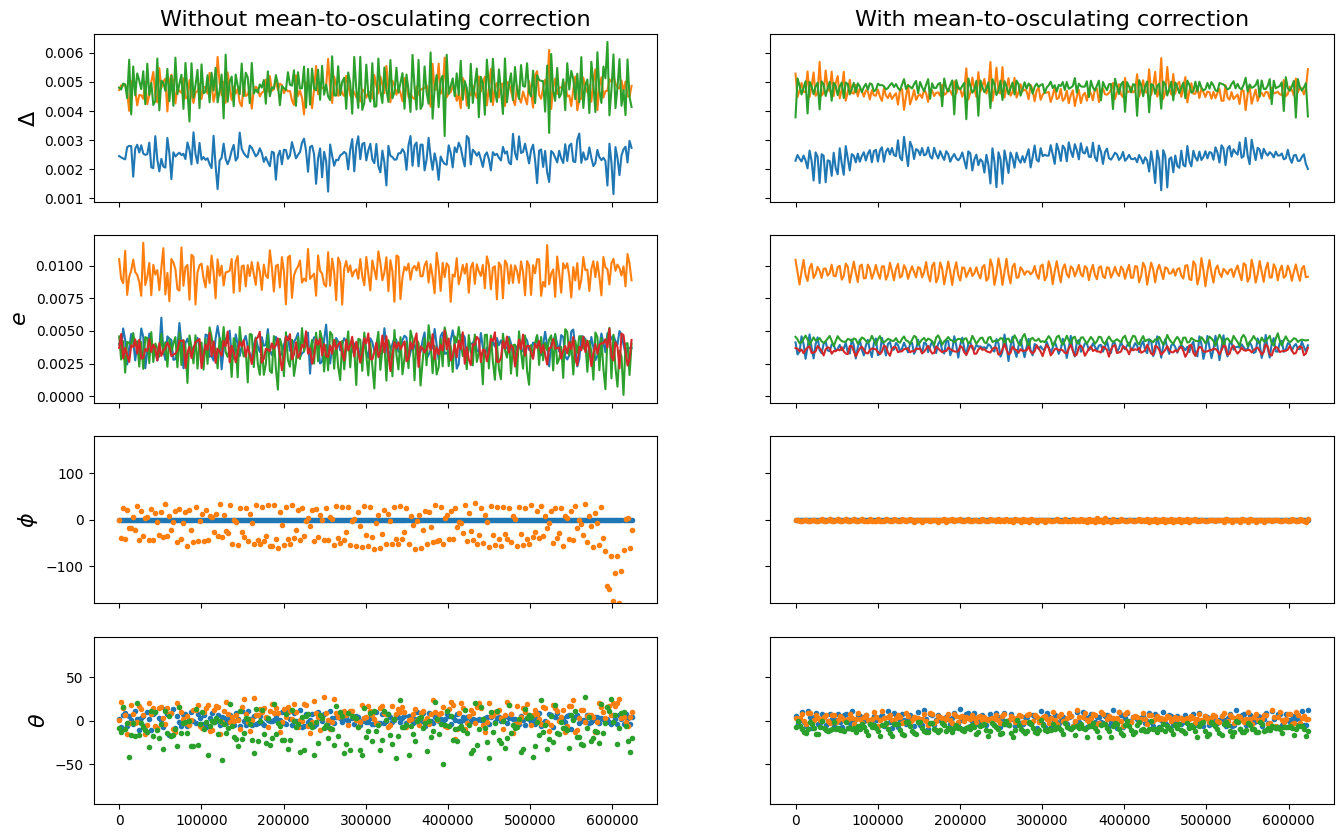

In [20]:
fig,ax_list = plt.subplots(4,2,sharex=True,figsize=(16,10),sharey='row')

ax_list[0,0].set_title("Without mean-to-osculating correction",fontsize=16)
ax_list[0,1].set_title("With mean-to-osculating correction",fontsize=16)

mymod = lambda x: np.mod(x+np.pi,2*np.pi)-np.pi
for finame,ax in zip(("kep223_eq_example.sa","kep223_eq_corrected_example.sa"),ax_list.T):
    results = cm.nbody_simulation_utilities.get_simarchive_integration_results(finame,coordinates='heliocentric')
    results['z'] = results['e']*np.exp(1j*results['pomega'])
    for jk,p1,p2 in zip(resonances,results['P'][:-1],results['P'][1:]):
        j,k = jk
        D = (j-k)*p2/p1/j-1
        ax[0].plot(results['time'],D)
    for ecc in results['e']:
        ax[1].plot(results['time'],ecc)

    for l,row in enumerate(rc.Tmtrx[2:2+rc.M,:rc.N_planar]):
        phi = mymod(l*(row @ results['l'] - (row @ results['l'])[0]))
        ax[2].plot(results['time'],180*phi/np.pi,'.')
    ax[2].set_ylim(-180,180)
    all_theta = []
    for l,jk in enumerate(resonances):
        j,k  = jk
        f,g = get_fg_coefficients(j,k)
        argZ = np.angle(f*results['z'][l]+g*results['z'][l+1])
        theta = mymod(j * results['l'][l+1] + (k-j)*results['l'][l] - k * argZ + np.pi)
        all_theta.append(theta)
        ax[3].plot(results['time'],180*theta/np.pi,'.')
    
    ax[3].set_ylim(-96,96)
ax_list[0,0].set_ylabel(r"$\Delta$",fontsize=16)
ax_list[1,0].set_ylabel(r"$e$",fontsize=16)
ax_list[2,0].set_ylabel(r"$\phi$",fontsize=16)
ax_list[3,0].set_ylabel(r"$\theta$",fontsize=16)